In [1]:
import numpy as np 
import pandas as pd
# from torchsummaryX import summary
# import nibabel                      as nib
# import nibabel.freesurfer.mghformat as mgh
import matplotlib.pyplot as plt
from datetime import datetime
import sklearn

import glob
import re

In [2]:
import os 
os.getcwd()


'/ocean/projects/cis230054p/ytam/Model'

In [3]:
# Optional: set project root manually
# os.chdir('<project_root>')

In [4]:
ADNI_actual_used_seg_df = pd.read_csv(r'ADNI_actual_used_seg_2.csv')


In [5]:
ADNI_actual_used_seg_df

,participant_id,session_id,age,sex,diagnosis,split
0,sub-ADNI021S0332,ses-M00,69.9,Male,1,train
1,sub-ADNI021S0332,ses-M06,69.9,Male,1,train
2,sub-ADNI021S0332,ses-M12,69.9,Male,1,train
3,sub-ADNI127S0754,ses-M00,67.7,Female,1,train
4,sub-ADNI127S0754,ses-M06,67.7,Female,1,train
...,...,...,...,...,...,...
2203,sub-ADNI062S1299,ses-M18,71.8,Male,1,train
2204,sub-ADNI062S1299,ses-M24,71.8,Male,1,train
2205,sub-ADNI062S1299,ses-M36,71.8,Male,1,train
2206,sub-ADNI100S0035,ses-M36,76.9,Male,0,train


In [6]:
# demographics



In [7]:
seg_path = r"./fastsurfer_stacked/fastsurfer_seg/{}_{}/mri/aparc.DKTatlas+aseg.deep.mgz"
# img_path = r"fastsurfer_seg_masked\masked_orig_nu_{}_{}.npy"
stacked_path = r"./fastsurfer_stacked/stacked_orig_seg_{}_{}.npy"
mor_path = r"mor_features_arrays/mor_features_{}_{}.npy"

In [8]:
# train



In [9]:
import os
import pandas as pd

def ADNI_unimodal_mor(csv_file, mor_path, split = 'train',):
    df = pd.read_csv(csv_file)

    if split == 'train':
        data = df[df.split == 'train'] 
    elif split == 'val':
        data = df[df.split == 'val'] 
    elif split == 'test':
        data = df[df.split == 'test'] 


    lst = []

    for i, d in data.iterrows():         

        subject_id = d['participant_id']
        session_id = d['session_id']
        # final_path = self.stacked_path.format(subject_id, session_id)
        final_mor_path = mor_path.format(subject_id, session_id)

        # morphological features, shape = (n, 700)
        mor_features = np.load(final_mor_path, allow_pickle=True).astype(np.float32)
        lst.append(mor_features)

    mor_features_arrays = np.array(lst)


    labels = data.iloc[:, 4]

    assert len(mor_features_arrays) == len(labels)

    return mor_features_arrays, labels

In [10]:
train_data = ADNI_unimodal_mor(csv_file= r'ADNI_actual_used_seg_2.csv',mor_path = mor_path,  split = 'train')
val_data = ADNI_unimodal_mor(r'ADNI_actual_used_seg_2.csv', mor_path = mor_path,  split = 'val')
test_data = ADNI_unimodal_mor(r'ADNI_actual_used_seg_2.csv', mor_path = mor_path, split = 'test')

In [11]:
len(test_data[0]), len(test_data[1])

(389, 389)

# Standardize data

In [12]:
from sklearn import preprocessing
import numpy as np

scaler = preprocessing.StandardScaler().fit(train_data[0])

X_train_scaled = scaler.transform(train_data[0])
X_test_scaled = scaler.transform(test_data[0])

# model 



## SVM

In [13]:
# # train
# from sklearn.svm import SVC
# svc = SVC(probability = True)

In [14]:
# svc.fit(train_data[0], train_data[1])

In [15]:
# train_preds_svc = svc.predict(train_data[0])
# val_preds_svc = svc.predict(val_data[0])
# test_preds_svc = svc.predict(test_data[0])

In [16]:
# # sklearn 
# import sklearn.metrics

# sklearn.metrics.f1_score(train_data[1], train_preds_svc)

In [17]:
# cm = sklearn.metrics.confusion_matrix(train_data[1], train_preds_svc)
# sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [18]:
# # print(f'Epoch: {epoch+1}')
# print(sklearn.metrics.classification_report(train_data[1], train_preds_svc))

In [19]:
# # sklearn 
# import sklearn.metrics

# sklearn.metrics.f1_score(test_data[1], test_preds_svc )

In [20]:
# cm = sklearn.metrics.confusion_matrix(test_data[1], test_preds_svc)
# sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [21]:
# # print(f'Epoch: {epoch+1}')
# print(sklearn.metrics.classification_report(test_data[1], test_preds_svc))

In [22]:
# test_prob_preds_svc = svc.predict_proba(test_data[0])

In [23]:
# print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_data[1], test_preds_svc)))
# print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_data[1], test_prob_preds_svc[:,1])))
# print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_data[1], test_prob_preds_svc[:,1], pos_label=1)))

In [24]:
# # sklearn 
# import sklearn.metrics

# sklearn.metrics.f1_score(val_data[1], val_preds)

In [25]:
# cm = sklearn.metrics.confusion_matrix(val_data[1], val_preds)
# sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [26]:
# # print(f'Epoch: {epoch+1}')
# print(sklearn.metrics.classification_report(val_data[1], val_preds))

## Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [28]:
lr.fit(train_data[0], train_data[1])

/opt/packages/anaconda3-2022.10/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [29]:
train_preds_lr = lr.predict(train_data[0])
val_preds_lr = lr.predict(val_data[0])
test_preds_lr = lr.predict(test_data[0])

## train

In [30]:
sklearn.metrics.f1_score(train_data[1], train_preds_lr)

0.9077757685352622

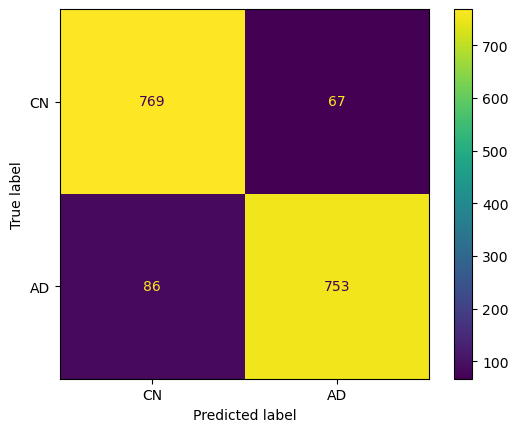

In [31]:
cm = sklearn.metrics.confusion_matrix(train_data[1], train_preds_lr)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [32]:
# print(f'Epoch: {epoch+1}')
print(sklearn.metrics.classification_report(train_data[1], train_preds_lr))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       836
           1       0.92      0.90      0.91       839

    accuracy                           0.91      1675
   macro avg       0.91      0.91      0.91      1675
weighted avg       0.91      0.91      0.91      1675



## val

In [33]:
sklearn.metrics.f1_score(val_data[1], val_preds_lr)

0.9315068493150684

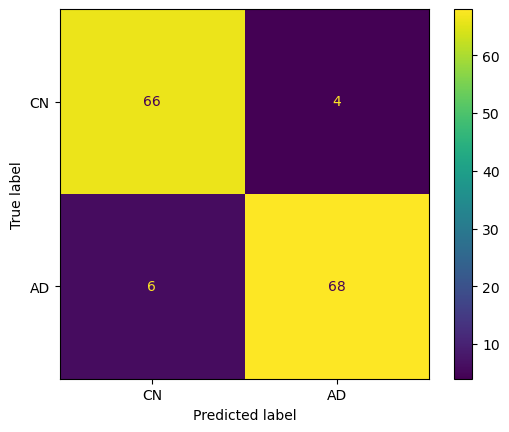

In [34]:
cm = sklearn.metrics.confusion_matrix(val_data[1], val_preds_lr)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [35]:
# print(f'Epoch: {epoch+1}')
print(sklearn.metrics.classification_report(val_data[1], val_preds_lr))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        70
           1       0.94      0.92      0.93        74

    accuracy                           0.93       144
   macro avg       0.93      0.93      0.93       144
weighted avg       0.93      0.93      0.93       144



## test

In [36]:
sklearn.metrics.f1_score(test_data[1], test_preds_lr)

0.8296296296296297

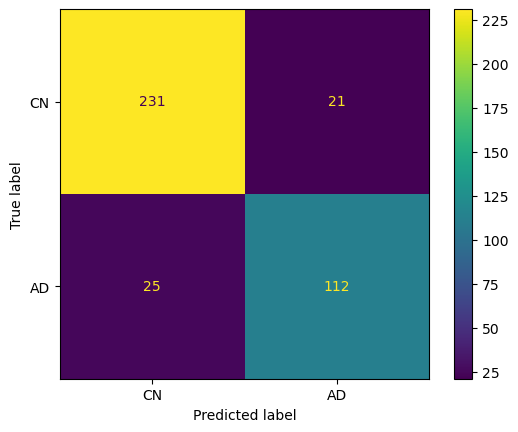

In [37]:
cm = sklearn.metrics.confusion_matrix(test_data[1], test_preds_lr)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [38]:
# print(f'Epoch: {epoch+1}')
print(sklearn.metrics.classification_report(test_data[1], test_preds_lr))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       252
           1       0.84      0.82      0.83       137

    accuracy                           0.88       389
   macro avg       0.87      0.87      0.87       389
weighted avg       0.88      0.88      0.88       389



In [39]:
test_prob_preds_lst = lr.predict_proba(test_data[0])

In [40]:
print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_data[1], test_preds_lr)))
print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_data[1], test_prob_preds_lst[:,1])))
print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_data[1], test_prob_preds_lst[:,1], pos_label=1)))

BA: 0.8670924574209246
AUROC: 0.9503244120032441
AUPRC: 0.9306010133332023


## Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0).fit(X_train_scaled, train_data[1])

In [42]:
val_preds_rf = rf.predict(scaler.transform(val_data[0]))
test_preds_rf = rf.predict(scaler.transform(test_data[0]))

In [43]:
sklearn.metrics.f1_score(val_data[1], val_preds_rf)

0.9305555555555555

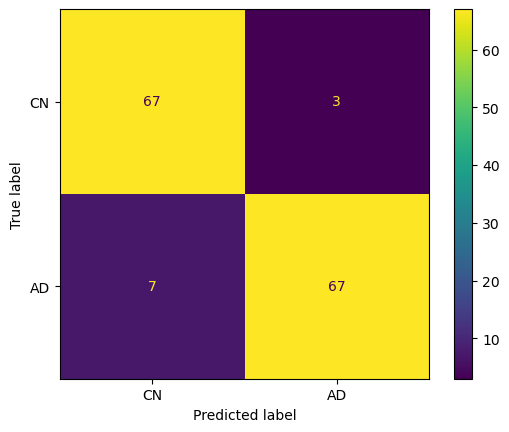

In [44]:
cm = sklearn.metrics.confusion_matrix(val_data[1], val_preds_rf)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

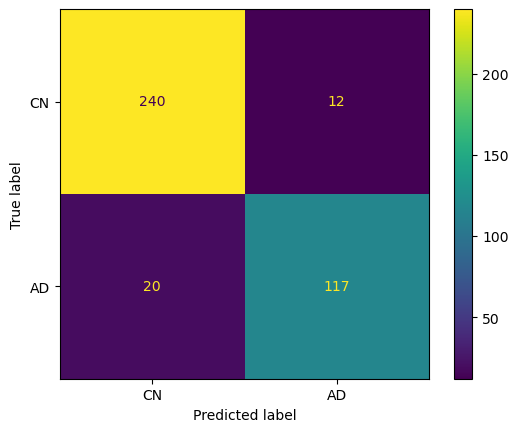

In [45]:
cm = sklearn.metrics.confusion_matrix(test_data[1], test_preds_rf)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [46]:
# print(f'Epoch: {epoch+1}')
print(sklearn.metrics.classification_report(test_data[1], test_preds_rf))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       252
           1       0.91      0.85      0.88       137

    accuracy                           0.92       389
   macro avg       0.92      0.90      0.91       389
weighted avg       0.92      0.92      0.92       389



In [47]:
test_prob_preds_lst = rf.predict_proba(scaler.transform(test_data[0]))

In [48]:
sklearn.metrics.roc_auc_score(test_data[1], test_prob_preds_lst[:,1])

0.9688332754026185

In [49]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(test_data[1], test_prob_preds_lst[:,1], pos_label=1)

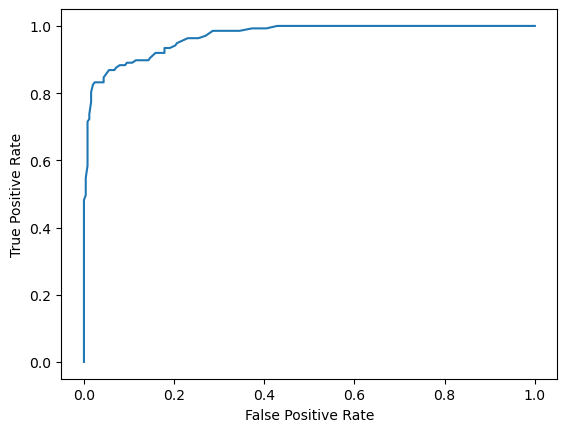

In [50]:
 sklearn.metrics.RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

In [51]:
 sklearn.metrics.average_precision_score(test_data[1], test_prob_preds_lst[:,1], pos_label=1)

0.9517265166610044

In [52]:
precision, recall, thresholds = sklearn.metrics.precision_recall_curve(test_data[1], test_prob_preds_lst[:,1], pos_label=1)

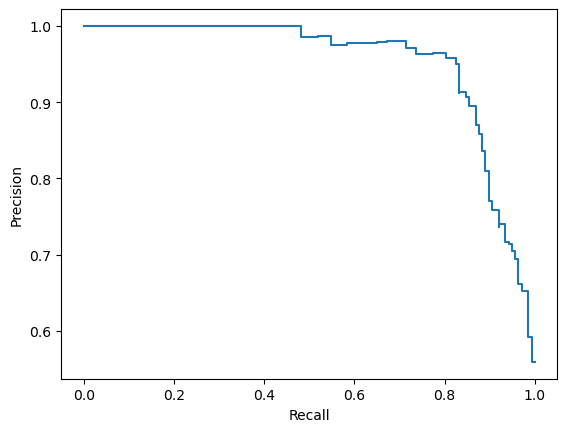

In [53]:
 sklearn.metrics.PrecisionRecallDisplay(precision, recall).plot()

In [54]:
print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_data[1], test_preds_rf)))
print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_data[1], test_prob_preds_lst[:,1])))
print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_data[1], test_prob_preds_lst[:,1], pos_label=1)))

BA: 0.9031977754605491
AUROC: 0.9688332754026185
AUPRC: 0.9517265166610044


In [55]:
import time

import numpy as np

start_time = time.time()
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 0.012 seconds


In [56]:
import pandas as pd

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize=(100,10))
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

NameError: name 'feature_names' is not defined

In [ ]:
from sklearn.inspection import permutation_importance

start_time = time.time()
result = permutation_importance(
    rf, scaler.transform(test_data[0]), test_data[1], n_repeats=10, random_state=0, n_jobs=2
)
elapsed_time = time.time() - start_time
print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

forest_importances = pd.Series(result.importances_mean, index=feature_names)

In [ ]:
fig, ax = plt.subplots(figsize=(100,10))
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

## LR

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [ ]:
lr.fit(X_scaled, train_data[1])

In [ ]:
val_preds_lr = lr.predict(scaler.transform(val_data[0]))
test_preds_lr = lr.predict(scaler.transform(test_data[0]))

In [ ]:
sklearn.metrics.f1_score(val_data[1], val_preds_lr)

In [ ]:
cm = sklearn.metrics.confusion_matrix(val_data[1], val_preds_lr)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [ ]:
# print(f'Epoch: {epoch+1}')
print(sklearn.metrics.classification_report(val_data[1], val_preds_lr))

In [ ]:
sklearn.metrics.f1_score(test_data[1], test_preds_lr)

In [ ]:
cm = sklearn.metrics.confusion_matrix(test_data[1], test_preds_lr)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [ ]:
# print(f'Epoch: {epoch+1}')
print(sklearn.metrics.classification_report(test_data[1], test_preds_lr))

In [ ]:
test_prob_preds_lst = lr.predict_proba(scaler.transform(test_data[0]))

In [ ]:
sklearn.metrics.roc_auc_score(test_data[1], test_prob_preds_lst[:,1])

In [ ]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(test_data[1], test_prob_preds_lst[:,1], pos_label=1)

In [ ]:
 sklearn.metrics.RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

In [ ]:
 sklearn.metrics.average_precision_score(test_data[1], test_prob_preds_lst[:,1], pos_label=1)

In [ ]:
precision, recall, thresholds = sklearn.metrics.precision_recall_curve(test_data[1], test_prob_preds_lst[:,1], pos_label=1)

In [ ]:
 sklearn.metrics.PrecisionRecallDisplay(precision, recall).plot()

In [ ]:
print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_data[1], test_preds_lr)))
print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_data[1], test_prob_preds_lst[:,1])))
print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_data[1], test_prob_preds_lst[:,1], pos_label=1)))

## SVM - normalized

In [57]:
# train
from sklearn.svm import SVC
svc = SVC(probability = True, random_state = 0).fit(X_train_scaled, train_data[1])

In [58]:
# val_preds_lr = lr.predict(scaler.transform(val_data[0]))
test_preds_svc = svc.predict(scaler.transform(test_data[0]))

In [59]:
test_prob_preds_svc = svc.predict_proba(scaler.transform(test_data[0]))

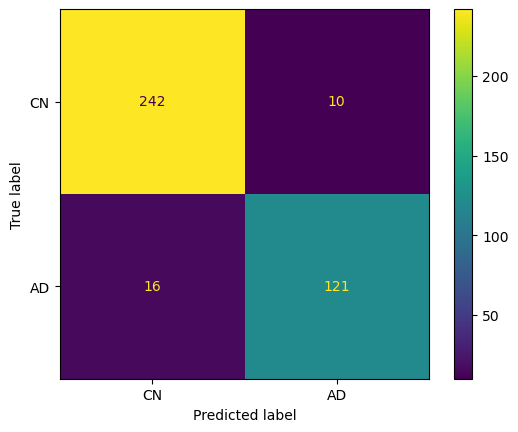

In [60]:
cm = sklearn.metrics.confusion_matrix(test_data[1], test_preds_svc)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [61]:
# print(f'Epoch: {epoch+1}')
print(sklearn.metrics.classification_report(test_data[1], test_preds_svc))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       252
           1       0.92      0.88      0.90       137

    accuracy                           0.93       389
   macro avg       0.93      0.92      0.93       389
weighted avg       0.93      0.93      0.93       389



In [62]:
print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_data[1], test_preds_svc)))
print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_data[1], test_prob_preds_svc[:,1])))
print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_data[1], test_prob_preds_svc[:,1], pos_label=1)))

BA: 0.9217645695747886
AUROC: 0.976914610126289
AUPRC: 0.9670600229350911


In [63]:
np.save('test_prob_preds_svc.npy',test_prob_preds_svc)

In [64]:
test_result_df = pd.concat([ADNI_actual_used_seg_df[ADNI_actual_used_seg_df.split == 'test'].reset_index(), pd.Series(test_preds_svc, name = 'unimodal_fastsurferstat_pred')],  axis = 1)

In [65]:
test_result_df

,index,participant_id,session_id,age,sex,diagnosis,split,unimodal_fastsurferstat_pred
0,95,sub-ADNI126S0891,ses-M06,79.3,Female,1,test,1
1,96,sub-ADNI126S0891,ses-M12,79.3,Female,1,test,1
2,97,sub-ADNI126S0891,ses-M24,79.3,Female,1,test,1
3,108,sub-ADNI114S0416,ses-M00,75.6,Female,0,test,0
4,109,sub-ADNI114S0416,ses-M06,75.6,Female,0,test,0
...,...,...,...,...,...,...,...,...
384,2186,sub-ADNI023S0058,ses-M24,70.1,Male,0,test,0
385,2187,sub-ADNI023S0058,ses-M48,70.1,Male,0,test,0
386,2188,sub-ADNI023S0058,ses-M60,70.1,Male,0,test,0
387,2189,sub-ADNI023S0058,ses-M72,70.1,Male,0,test,0


In [66]:
test_result_df.sort_values(by = 'age', inplace = True)

In [67]:
test_result_df['unimodal_fastsurferstat_error'] = abs(test_result_df.unimodal_fastsurferstat_pred - test_result_df.diagnosis)

In [68]:
test_result_df

,index,participant_id,session_id,age,sex,diagnosis,split,unimodal_fastsurferstat_pred,unimodal_fastsurferstat_error
352,1981,sub-ADNI009S1354,ses-M00,58.9,Female,1,test,1,0
353,1982,sub-ADNI009S1354,ses-M06,58.9,Female,1,test,1,0
209,1223,sub-ADNI033S1283,ses-M00,59.9,Male,1,test,1,0
210,1224,sub-ADNI033S1283,ses-M06,59.9,Male,1,test,1,0
241,1372,sub-ADNI020S1288,ses-M60,59.9,Male,0,test,0,0
...,...,...,...,...,...,...,...,...,...
347,1976,sub-ADNI002S0685,ses-M06,89.6,Female,0,test,0,0
346,1975,sub-ADNI002S0685,ses-M00,89.6,Female,0,test,0,0
351,1980,sub-ADNI002S0685,ses-M48,89.6,Female,0,test,0,0
350,1979,sub-ADNI002S0685,ses-M36,89.6,Female,0,test,0,0


In [69]:
test_result_df.to_csv('test_result_(unimodal_fastsurfer_stat)_df.csv', index = False)

In [70]:
X_scaled

NameError: name 'X_scaled' is not defined

# Feature Importances

## read feature names

In [71]:
mor_feature_df = pd.read_csv(r'./mor_feature_df.csv')

In [91]:
mor_feature_df

,SegId,StructName
0,2,Left-Cerebral-White-Matter
1,4,Left-Lateral-Ventricle
2,5,Left-Inf-Lat-Vent
3,7,Left-Cerebellum-White-Matter
4,8,Left-Cerebellum-Cortex
...,...,...
95,2029,ctx-rh-superiorparietal
96,2030,ctx-rh-superiortemporal
97,2031,ctx-rh-supramarginal
98,2034,ctx-rh-transversetemporal


In [72]:
mor_feature_df.StructName

0       Left-Cerebral-White-Matter
1           Left-Lateral-Ventricle
2                Left-Inf-Lat-Vent
3     Left-Cerebellum-White-Matter
4           Left-Cerebellum-Cortex
                  ...             
95         ctx-rh-superiorparietal
96         ctx-rh-superiortemporal
97            ctx-rh-supramarginal
98       ctx-rh-transversetemporal
99                   ctx-rh-insula
Name: StructName, Length: 100, dtype: object

In [73]:
full_feature_lst = []
for i in mor_feature_df.StructName:
    for j in ['NVoxels', 'Volume_mm3', 'normMean', 'normStdDev', 'normMin', 'normMax',
       'normRange']:
        full_feature_lst.append(f'{i}_{j}')
    

In [74]:
import pickle

with open("mor_feature_names_lst.pkl", "wb") as f:   #Pickling
    pickle.dump(full_feature_lst, f)
 
# with open("test", "rb") as fp:   # Unpickling
#     b = pickle.load(fp)



In [75]:
from sklearn.inspection import permutation_importance


perm_importance = permutation_importance(svc, scaler.transform(test_data[0]), test_data[1], random_state = 0)

feature_names = full_feature_lst
features = np.array(feature_names)



KeyboardInterrupt: 

In [ ]:
perm_importance.keys()

In [ ]:
perm_importance.importances.shape


In [79]:
# datetime
from datetime import datetime

# Get the current date and time
current_datetime = datetime.now()

# Format date and time together as a string
formatted_datetime = current_datetime.strftime('%Y%m%d_%H%M%S')  # YYYY-MM-DD HH:MM:SS format

print("Formatted Date and Time:", formatted_datetime)

Formatted Date and Time: 20240222_083255


In [ ]:
pd.Series(perm_importance.importances_mean, index = features).sort_values(ascending = False).reset_index().to_csv(f'SVM_mor_only_perm_importance_{formatted_datetime}.csv', index = False)

In [76]:
pd.read_csv('SVM_mor_only_perm_importance.csv').iloc[:10]

,index,0
0,ctx-rh-entorhinal_normMax,0.005141
1,Right-Hippocampus_Volume_mm3,0.004627
2,ctx-rh-pericalcarine_Volume_mm3,0.004113
3,ctx-rh-entorhinal_NVoxels,0.004113
4,ctx-lh-inferiortemporal_NVoxels,0.003599
5,ctx-rh-cuneus_normMax,0.003599
6,ctx-lh-inferiortemporal_Volume_mm3,0.003599
7,ctx-rh-pericalcarine_normMin,0.003599
8,ctx-rh-entorhinal_Volume_mm3,0.003599
9,ctx-lh-entorhinal_Volume_mm3,0.003599


In [ ]:
sorted_idx = perm_importance.importances_mean.argsort()
plt.figure(figsize=(10,100))
plt.barh(features[sorted_idx],perm_importance.importances_mean[sorted_idx] ) 

plt.xlabel("Permutation Importance")

NameError: name 'perm_importance' is not defined

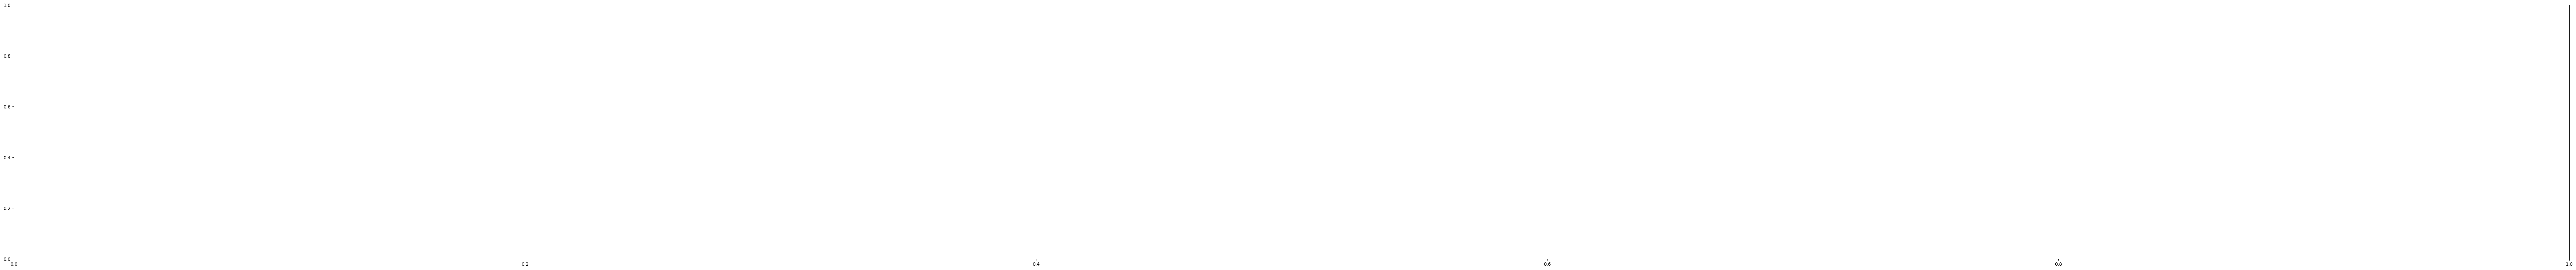

In [80]:
fig, ax = plt.subplots(figsize=(100,10))
svc_importances = pd.Series(perm_importance.importances_mean, index=feature_names)
svc_importances.plot.bar(yerr=perm_importance.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

# XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
import xgboost
#https://xgboost.readthedocs.io/en/stable/parameter.html
# https://github.com/dmlc/xgboost/blob/master/demo/guide-python/gamma_regression.py
# create model instance
bst = XGBClassifier(feature_names=full_feature_lst) # default logistic objective='binary:logistic' can chose  objective='binary:hinge', result is poor
# fit model
bst.fit(X_train_scaled, train_data[1])
# X_train_scaled = pd.DataFrame(X_train_scaled, columns = full_feature_lst)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns = full_feature_lst)
# dtrain = xgboost.DMatrix(X_train_scaled , label=train_data[1])
# dtest = xgboost.DMatrix(X_test_scaled , label=test_data[1])
# bst = xgboost.train({'objective' :'binary:logistic'} ,dtrain)
# make predictions
test_preds_xgb = bst.predict(X_test_scaled)
test_prob_preds_xgb = bst.predict_proba(X_test_scaled)

In [ ]:
print(bst)

In [ ]:
print('F1:' + str(sklearn.metrics.f1_score(test_data[1], test_preds_xgb, average = 'micro')))
print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_data[1], test_preds_xgb)))
print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_data[1], test_prob_preds_xgb[:,1])))
print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_data[1], test_prob_preds_xgb[:,1], pos_label=1)))

In [ ]:
# https://stackoverflow.com/questions/46943314/xgboost-plot-importance-doesnt-show-feature-names

In [ ]:
from xgboost import plot_importance


fig, ax = plt.subplots(figsize = (10, 50))

plot_importance(bst, ax = ax, )
plt.show()

In [ ]:
from xgboost import XGBClassifier

#https://xgboost.readthedocs.io/en/stable/parameter.html
# create model instance
bst = XGBClassifier(objective='binary:hinge') # default logistic objective='binary:logistic' can chose  objective='binary:hinge', result is poor
# fit model
bst.fit(X_train_scaled, train_data[1])
# make predictions
test_preds_xgb = bst.predict(X_test_scaled)
test_prob_preds_xgb = bst.predict_proba(X_test_scaled)

print('F1:' + str(sklearn.metrics.f1_score(test_data[1], test_preds_xgb, average = 'micro')))
print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_data[1], test_preds_xgb)))
print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_data[1], test_prob_preds_xgb[:,1])))
print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_data[1], test_prob_preds_xgb[:,1], pos_label=1)))

In [ ]:
# https://machinelearningmastery.com/feature-importance-and-feature-selection-with-xgboost-in-python/

# Feature Selection

In [81]:
train_data[0]

array([[2.5946900e+05, 2.6594906e+05, 1.0180320e+02, ..., 3.8000000e+01,
        8.9000000e+01, 5.1000000e+01],
       [2.5866800e+05, 2.6600456e+05, 1.0193140e+02, ..., 3.8000000e+01,
        1.0400000e+02, 6.6000000e+01],
       [2.5195700e+05, 2.5886756e+05, 1.0161500e+02, ..., 3.6000000e+01,
        9.3000000e+01, 5.7000000e+01],
       ...,
       [3.1340900e+05, 3.1891894e+05, 1.0159580e+02, ..., 3.5000000e+01,
        8.9000000e+01, 5.4000000e+01],
       [3.2661600e+05, 3.3171066e+05, 1.0326150e+02, ..., 4.0000000e+01,
        9.4000000e+01, 5.4000000e+01],
       [2.7241000e+05, 2.7716112e+05, 1.0206320e+02, ..., 4.1000000e+01,
        9.6000000e+01, 5.5000000e+01]], dtype=float32)

In [163]:
topk_lst = [10, 20, 30, 50, 100, 200, 350, 500]
gain_lst = [0.05, 0.1, 0.15, 0.2]

In [83]:
from sklearn.feature_selection import mutual_info_classif


#https://www.kaggle.com/code/pabangiri/feature-selection-using-information-gain
mutual_info= mutual_info_classif(X_train_scaled, train_data[1], random_state = 0)

In [93]:
mutual_info = pd.Series(mutual_info)
mutual_info.index =full_feature_lst
mutual_info.sort_values(ascending=False)

Left-Hippocampus_Volume_mm3          0.305872
Right-Hippocampus_Volume_mm3         0.264989
Left-Hippocampus_NVoxels             0.260327
Right-Hippocampus_NVoxels            0.253342
ctx-rh-entorhinal_Volume_mm3         0.252142
                                       ...   
Right-VentralDC_normMax              0.000000
ctx-lh-isthmuscingulate_normRange    0.000000
Right-VentralDC_normRange            0.000000
ctx-rh-lateraloccipital_normRange    0.000000
CC_Mid_Posterior_normStdDev          0.000000
Length: 700, dtype: float64

<AxesSubplot:>

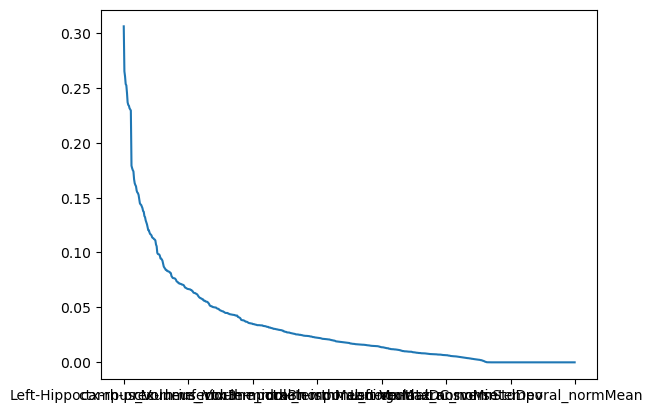

In [88]:
mutual_info_sorted.plot()

In [ ]:
mutual_info.sort_values(ascending=False).to_csv('./mutual_info.csv')

In [106]:
mutual_info_series = mutual_info.reset_index()
mutual_info_series.columns = ['name','value']

# Top K

In [102]:
k=10

In [ ]:
def train_predict(X_train_scaled, y_train, X_test_scaled, y_test):
    import sklearn
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC
    from sklearn.ensemble import RandomForestClassifier
    # from sklearn.metrics import classification_report

    feature_names = X_train.columns

    # fit
    base_lr = LogisticRegression().fit(X_train_scaled, y_train)
    base_svc = SVC(probability= True).fit(X_train_scaled, y_train)
    base_rf = RandomForestClassifier().fit(X_train_scaled, y_train)

    # train set
    y_train_pred_base_lr = base_lr.predict(X_train_scaled)
    y_train_pred_base_svc = base_svc.predict(X_train_scaled)
    y_train_pred_base_rf = base_rf.predict(X_train_scaled)

    # test set
    y_pred_base_lr = base_lr.predict(X_test_scaled)
    y_pred_base_svc = base_svc.predict(X_test_scaled)
    y_pred_base_rf = base_rf.predict(X_test_scaled)

    # train classification report
    train_report_base_lr = sklearn.metrics.classification_report(y_train, y_train_pred_base_lr, )
    train_report_base_svc = sklearn.metrics.classification_report(y_train, y_train_pred_base_svc,)
    train_report_base_rf = sklearn.metrics.classification_report(y_train, y_train_pred_base_rf, )
    print('LR - Train\n', train_report_base_lr,'\nSVC- Train\n', train_report_base_svc, '\nRF- Train\n',train_report_base_rf)


    print()
    test_report_base_lr = sklearn.metrics.classification_report(y_test, y_pred_base_lr, )
    test_report_base_svc = sklearn.metrics.classification_report(y_test, y_pred_base_svc,)
    test_report_base_rf = sklearn.metrics.classification_report(y_test, y_pred_base_rf, )
    print('LR - Test\n', test_report_base_lr,'\nSVC- Test\n', test_report_base_svc, '\nRF- Test\n',test_report_base_rf)

    return y_pred_base_lr,  y_pred_base_svc, y_pred_base_rf, base_lr, base_svc, base_rf

In [161]:
def topk_experiment(X_train, y_train, X_test, y_test, topk_lst = [10, 20, 30, 50, 100, 200, 350]):
    from sklearn import preprocessing
    import numpy as np
    from sklearn.svm import SVC
    from datetime import datetime

    # Get the current date and time
    current_datetime = datetime.now()

    # Format date and time together as a string
    formatted_datetime = current_datetime.strftime('%Y%m%d_%H%M%S')  # YYYY-MM-DD HH:MM:SS format

    print("Formatted Date and Time:", formatted_datetime)
    preds_dict = dict()
    proba_preds_dict = dict()
    eval_dict = dict()
    cm_dict = dict()
    class_report_dict = dict()
    
    for k in topk_lst:
        # choose topk
        ind = np.argpartition(mutual_info_series.value, -k)[-k:]
        topk = mutual_info_series.iloc[ind]
        
        print('Current k:', k)
        print('Top k features:', topk)
        print()
        # scale data
        scaler = preprocessing.StandardScaler().fit(X_train[:, topk.index])

        topk_X_train_scaled = scaler.transform(X_train[:, topk.index])
        topk_X_test_scaled = scaler.transform(X_test[:, topk.index])
        
        
        # train
        topk_svc = SVC(probability = True, random_state = 0).fit(topk_X_train_scaled, y_train) 
        test_preds_svc = topk_svc.predict(topk_X_test_scaled)
        test_prob_preds_svc = topk_svc.predict_proba(topk_X_test_scaled)
        
        class_report = sklearn.metrics.classification_report(y_test, test_preds_svc)
        
        cm = sklearn.metrics.confusion_matrix(y_test, test_preds_svc)
        # cm_display = sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD'])
        
#         cm_display.plot()
#         cm_display.ax_.set_title(f'Top k = {k}')

        f1 = sklearn.metrics.f1_score(y_test, test_preds_svc, average = 'micro')
        ba = sklearn.metrics.balanced_accuracy_score(y_test, test_preds_svc)
        aupoc = sklearn.metrics.roc_auc_score(y_test, test_prob_preds_svc[:,1])
        auprc = sklearn.metrics.average_precision_score(y_test, test_prob_preds_svc[:,1], pos_label=1)
        
        print(class_report)
        print()
        print('F1:' + str(f1))
        print('BA: '+ str(ba))
        print('AUROC: '+ str(aupoc))
        print('AUPRC: '+ str(auprc))
        print('---------------------------------------------------------------------------------------')
        
        
        # save
        preds_dict[k] = test_preds_svc
        proba_preds_dict[k] = test_prob_preds_svc
        eval_dict[k] = [f1, ba, aupoc, auprc]
        cm_dict[k] = cm
        class_report_dict[k] = class_report
        
    return preds_dict, proba_preds_dict, eval_dict, cm_dict, class_report_dict
        

In [164]:
preds_dict, proba_preds_dict, eval_dict, cm_dict, class_report_dict = topk_experiment(train_data[0], train_data[1], test_data[0], test_data[1], topk_lst = topk_lst)

Formatted Date and Time: 20240222_092527
Current k: 10
Top k features:                              name     value
196        Right-Amygdala_NVoxels  0.231289
288  ctx-lh-entorhinal_Volume_mm3  0.233618
505  ctx-rh-entorhinal_Volume_mm3  0.252142
504     ctx-rh-entorhinal_NVoxels  0.236682
91          Left-Amygdala_NVoxels  0.234342
92       Left-Amygdala_Volume_mm3  0.245390
189     Right-Hippocampus_NVoxels  0.253342
84       Left-Hippocampus_NVoxels  0.260327
85    Left-Hippocampus_Volume_mm3  0.305872
190  Right-Hippocampus_Volume_mm3  0.264989

              precision    recall  f1-score   support

           0       0.89      0.96      0.93       252
           1       0.92      0.79      0.85       137

    accuracy                           0.90       389
   macro avg       0.90      0.87      0.89       389
weighted avg       0.90      0.90      0.90       389


F1:0.8997429305912596
BA: 0.874319314100336
AUROC: 0.9247190360329045
AUPRC: 0.8910276318216508
--------------------

In [ ]:
def eval(results_df):
    class_report = classification_report(results_df['Label'] , results_df['Preds_bin'])
    print(class_report)
    fpr, tpr, thresholds = roc_curve(results_df['Label'] , results_df['Preds'], pos_label=True)

    auroc = auc(fpr, tpr)
    auprc = average_precision_score(results_df['Label'] , results_df['Preds'], pos_label=True)
    print('AUROC:', auroc)
    print('AUPRC:', auprc)

    return class_report, auroc, auprc


# cutoff

In [169]:
mutual_info_series[mutual_info_series.value > 0.05].index

Int64Index([  3,   7,   8,  10,  14,  15,  16,  17,  33,  35,
            ...
            652, 659, 672, 673, 675, 680, 682, 689, 694, 696],
           dtype='int64', length=142)

In [172]:
def cutoffs_experiment(X_train, y_train, X_test, y_test, cutoff_lst = [0.05, 0.1, 0.15, 0.2]):
    from sklearn import preprocessing
    import numpy as np
    from sklearn.svm import SVC
    from datetime import datetime

    # Get the current date and time
    current_datetime = datetime.now()

    # Format date and time together as a string
    formatted_datetime = current_datetime.strftime('%Y%m%d_%H%M%S')  # YYYY-MM-DD HH:MM:SS format

    print("Formatted Date and Time:", formatted_datetime)
    preds_dict = dict()
    proba_preds_dict = dict()
    eval_dict = dict()
    cm_dict = dict()
    class_report_dict = dict()
    
    for c in cutoff_lst:
        # choose topk
        
        cutoff_df = mutual_info_series[mutual_info_series.value > c]
        
        print('Current c:', c)
        print('cutoff c features:', cutoff_df)
        print()
        # scale data
        scaler = preprocessing.StandardScaler().fit(X_train[:, cutoff_df.index])

        topk_X_train_scaled = scaler.transform(X_train[:, cutoff_df.index])
        topk_X_test_scaled = scaler.transform(X_test[:, cutoff_df.index])
        
        
        # train
        topk_svc = SVC(probability = True, random_state = 0).fit(topk_X_train_scaled, y_train) 
        test_preds_svc = topk_svc.predict(topk_X_test_scaled)
        test_prob_preds_svc = topk_svc.predict_proba(topk_X_test_scaled)
        
        class_report = sklearn.metrics.classification_report(y_test, test_preds_svc)
        
        cm = sklearn.metrics.confusion_matrix(y_test, test_preds_svc)
        # cm_display = sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD'])
        
#         cm_display.plot()
#         cm_display.ax_.set_title(f'Top k = {k}')

        f1 = sklearn.metrics.f1_score(y_test, test_preds_svc, average = 'micro')
        ba = sklearn.metrics.balanced_accuracy_score(y_test, test_preds_svc)
        aupoc = sklearn.metrics.roc_auc_score(y_test, test_prob_preds_svc[:,1])
        auprc = sklearn.metrics.average_precision_score(y_test, test_prob_preds_svc[:,1], pos_label=1)
        
        print(class_report)
        print()
        print('F1:' + str(f1))
        print('BA: '+ str(ba))
        print('AUROC: '+ str(aupoc))
        print('AUPRC: '+ str(auprc))
        print('---------------------------------------------------------------------------------------')
        
        
        # save
        preds_dict[k] = test_preds_svc
        proba_preds_dict[k] = test_prob_preds_svc
        eval_dict[k] = [f1, ba, aupoc, auprc]
        cm_dict[k] = cm
        class_report_dict[k] = class_report
        
    return preds_dict, proba_preds_dict, eval_dict, cm_dict, class_report_dict
        

In [173]:
preds_dict, proba_preds_dict, eval_dict, cm_dict, class_report_dict = cutoffs_experiment(train_data[0], train_data[1], test_data[0], test_data[1], cutoff_lst = [0.05, 0.1, 0.15, 0.2])

Formatted Date and Time: 20240222_100801
Current c: 0.05
cutoff c features:                                       name     value
3    Left-Cerebral-White-Matter_normStdDev  0.063486
7           Left-Lateral-Ventricle_NVoxels  0.082393
8        Left-Lateral-Ventricle_Volume_mm3  0.073663
10       Left-Lateral-Ventricle_normStdDev  0.069142
14               Left-Inf-Lat-Vent_NVoxels  0.144858
..                                     ...       ...
680        ctx-rh-supramarginal_Volume_mm3  0.066374
682        ctx-rh-supramarginal_normStdDev  0.065783
689   ctx-rh-transversetemporal_normStdDev  0.070475
694               ctx-rh-insula_Volume_mm3  0.066608
696               ctx-rh-insula_normStdDev  0.129237

[142 rows x 2 columns]

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       252
           1       0.90      0.83      0.87       137

    accuracy                           0.91       389
   macro avg       0.91      0.89      0.90  